<a href="https://colab.research.google.com/github/niloofarmaani/Are-Binns-just-GNNs-/blob/main/BINN_GINN_phase3_to6_visual_equivalence_tcga_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3: BINN-exact forward pass (no training)

This notebook implements the **BINN-exact GNN replica** described in the design plan:

- **Scalar node state** (`d = 1`)
- **Unique learnable weight per edge** (like a masked linear layer)
- **Sequential layer-by-layer propagation** over the **layered Reactome graph** created in Phase 2
- **BINN-like readout** from the top-level (root) pathways

This notebook does **not** train the model. It only:
1. Loads the cached layered graph artifacts from Phase 2
2. Builds per-layer edge lists (`edge_index_by_layer`, `edge_id_by_layer`)
3. Defines a BINN-exact forward pass
4. Runs a small smoke test (random gene expression) to verify shapes
5. Saves the per-layer edge artifacts so later training is simple


## 1. Paths and inputs

This assumes you ran the Phase 1 and Phase 2 notebooks and have `outputs/graph_layered_binn/`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import json
import pandas as pd
import torch
import numpy as np

# Change this if your folder is different
BASE_DIR = Path("/content/drive/MyDrive/binn_gnn_tcga")
OUT_DIR = BASE_DIR / "outputs"

LAYERED_GRAPH_DIR = OUT_DIR / "graph_layered_binn"
assert LAYERED_GRAPH_DIR.exists(), f"Missing {LAYERED_GRAPH_DIR}. Run Phase 2 first."

node_table_layered = pd.read_csv(LAYERED_GRAPH_DIR / "node_table_layered.csv")
edge_table_layered = pd.read_csv(LAYERED_GRAPH_DIR / "edge_table_layered.csv")
edge_index_layered = torch.load(LAYERED_GRAPH_DIR / "edge_index_layered.pt")

with open(LAYERED_GRAPH_DIR / "layer_info.json", "r") as f:
    layer_info = json.load(f)

L = int(layer_info["L"])
N_layered = int(layer_info["num_layered_nodes"])
E_layered = int(layer_info["num_layered_edges"])
root_layered_ids = torch.tensor(layer_info["root_pathways_layered_ids"], dtype=torch.long)

print("Layered graph:")
print(" - L:", L)
print(" - N_layered:", N_layered)
print(" - E_layered:", E_layered)
print(" - Root pathways at final layer:", len(root_layered_ids))

# Sanity checks
assert node_table_layered["layered_id"].min() == 0
assert node_table_layered["layered_id"].max() == N_layered - 1
assert edge_index_layered.shape == (2, E_layered)

Layered graph:
 - L: 12
 - N_layered: 16283
 - E_layered: 44955
 - Root pathways at final layer: 29


## 2. Build per-layer edge lists

We group edges by **destination layer**. Since Phase 2 ensured every edge goes from layer ℓ to layer ℓ+1, this creates the BINN feedforward schedule.

In [ ]:
# Layer per node (indexed by layered_id)
layer_of_node = node_table_layered.sort_values("layered_id")["layer"].to_numpy(dtype=np.int64)

src = edge_index_layered[0].cpu().numpy()
dst = edge_index_layered[1].cpu().numpy()

dst_layer = layer_of_node[dst]  # destination layer in 1..L
deltas = dst_layer - layer_of_node[src]

# Validate the feedforward property
u, c = np.unique(deltas, return_counts=True)
print("Edge delta counts:", dict(zip(u.tolist(), c.tolist())))
assert np.all(deltas == 1), "Expected all edges to be layer ℓ -> ℓ+1. Re-run Phase 2."

# Assign a stable edge id for each edge in the saved order
edge_id = np.arange(E_layered, dtype=np.int64)

edge_index_by_layer = []
edge_id_by_layer = []
dst_nodes_by_layer = []

for l in range(1, L + 1):
    m = (dst_layer == l)
    ei = np.vstack([src[m], dst[m]])
    eids = edge_id[m]
    edge_index_by_layer.append(torch.tensor(ei, dtype=torch.long))
    edge_id_by_layer.append(torch.tensor(eids, dtype=torch.long))
    dst_nodes_by_layer.append(torch.unique(edge_index_by_layer[-1][1]))
    print(f"Layer {l}: edges={ei.shape[1]} nodes(updated)={dst_nodes_by_layer[-1].numel()}")

# Save for training notebooks later
torch.save(edge_index_by_layer, LAYERED_GRAPH_DIR / "edge_index_by_layer.pt")
torch.save(edge_id_by_layer, LAYERED_GRAPH_DIR / "edge_id_by_layer.pt")
torch.save(dst_nodes_by_layer, LAYERED_GRAPH_DIR / "dst_nodes_by_layer.pt")

print("Saved:")
print(" - edge_index_by_layer.pt")
print(" - edge_id_by_layer.pt")
print(" - dst_nodes_by_layer.pt")

Edge delta counts: {1: 44955}
Layer 1: edges=40059 nodes(updated)=1971
Layer 2: edges=1986 nodes(updated)=1092
Layer 3: edges=1103 nodes(updated)=643
Layer 4: edges=643 nodes(updated)=402
Layer 5: edges=415 nodes(updated)=241
Layer 6: edges=245 nodes(updated)=150
Layer 7: edges=152 nodes(updated)=115
Layer 8: edges=115 nodes(updated)=82
Layer 9: edges=82 nodes(updated)=64
Layer 10: edges=64 nodes(updated)=46
Layer 11: edges=46 nodes(updated)=45
Layer 12: edges=45 nodes(updated)=29
Saved:
 - edge_index_by_layer.pt
 - edge_id_by_layer.pt
 - dst_nodes_by_layer.pt


## 3. BINN-exact forward pass

We implement the scalar update

\[
 h_u^{(l)} = \tanh\Big(b_u + \sum_{v \in \mathcal{N}_{in}(u)} w_{v\to u}\, h_v^{(l-1)}\Big)
\]

with **unique weights per edge**.

We also keep track of padding edges so you can either:
- treat padding as a fixed identity (weight = 1), or
- learn padding weights like any other edge.


In [ ]:
import torch.nn as nn

# Identify edge types
edge_type = edge_table_layered["edge_type"].astype(str).to_numpy()
is_padding_edge = torch.tensor(edge_type == "padding_identity", dtype=torch.bool)

class BINNExactLayered(nn.Module):
    def __init__(self, N, E, L, root_ids, is_padding_edge, learn_padding=False):
        super().__init__()
        self.N = N
        self.E = E
        self.L = L
        self.root_ids = root_ids
        self.is_padding_edge = is_padding_edge
        self.learn_padding = learn_padding

        # Unique scalar weight per edge
        self.edge_weight = nn.Parameter(torch.zeros(E))
        nn.init.normal_(self.edge_weight, mean=0.0, std=0.01)

        # Scalar bias per node
        self.node_bias = nn.Parameter(torch.zeros(N))

    @staticmethod
    def _layer_message_pass(h, edge_index, edge_w, N):
        # h: [N] scalar activations
        src = edge_index[0]
        dst = edge_index[1]
        msg = h[src] * edge_w  # [E_l]
        out = torch.zeros((N,), device=h.device, dtype=h.dtype)
        out.index_add_(0, dst, msg)
        return out

    def forward(self, h0, edge_index_by_layer, edge_id_by_layer, dst_nodes_by_layer):
        # h0: [N] initial state (genes filled, pathways 0)
        h = h0.clone()

        for l in range(1, self.L + 1):
            ei = edge_index_by_layer[l-1].to(h.device)
            eids = edge_id_by_layer[l-1].to(h.device)

            w = self.edge_weight[eids]

            # Optional: enforce padding edges = 1.0
            if not self.learn_padding:
                pad_mask = self.is_padding_edge[eids].to(h.device)
                if pad_mask.any():
                    w = w.clone()
                    w[pad_mask] = 1.0

            agg = self._layer_message_pass(h, ei, w, self.N)

            dst_nodes = dst_nodes_by_layer[l-1].to(h.device)
            h[dst_nodes] = torch.tanh(agg[dst_nodes] + self.node_bias[dst_nodes])

        # BINN-like readout: return root pathway activations at the final layer
        return h[self.root_ids]

# Instantiate model (no training)
model = BINNExactLayered(
    N=N_layered,
    E=E_layered,
    L=L,
    root_ids=root_layered_ids,
    is_padding_edge=is_padding_edge,
    learn_padding=False,  # start with identity padding
)

print(model)

BINNExactLayered()


## 4. Smoke test on one synthetic sample

We fill gene nodes (layer 0) with random values and keep all pathway nodes at 0, then run the forward pass.

This is only to verify:
- the forward pass runs without errors
- the output has the expected shape `(num_root_pathways,)`


In [ ]:
# Build synthetic input: genes random, pathways zero
num_genes = int((node_table_layered["node_type"] == "gene").sum())
assert num_genes > 0

h0 = torch.zeros((N_layered,), dtype=torch.float32)
h0[:num_genes] = torch.randn((num_genes,), dtype=torch.float32)

# Load per-layer lists saved earlier (or reuse in-memory)
edge_index_by_layer = torch.load(LAYERED_GRAPH_DIR / "edge_index_by_layer.pt")
edge_id_by_layer = torch.load(LAYERED_GRAPH_DIR / "edge_id_by_layer.pt")
dst_nodes_by_layer = torch.load(LAYERED_GRAPH_DIR / "dst_nodes_by_layer.pt")

with torch.no_grad():
    root_act = model(h0, edge_index_by_layer, edge_id_by_layer, dst_nodes_by_layer)

print("Root activations shape:", tuple(root_act.shape))
print("First 10 root activations:", root_act[:10])

Root activations shape: (29,)
First 10 root activations: tensor([-3.0122e-04,  3.7216e-06, -2.0500e-03, -4.1959e-04, -6.6692e-05,
         2.5696e-05,  1.6493e-05,  1.6595e-04,  1.0975e-06, -3.6604e-06])


## 5. Phase 4: Load a small TCGA slice for real-data validation

In Phase 1, we saved a **Reactome-mapped TCGA expression matrix** (`expr`, genes × samples) and the corresponding labels (`y`).
Here we load **only a couple of samples** (one normal and one tumor) to keep memory use low.

This is just a wiring check: do real TCGA gene values flow into the layered graph correctly?


In [ ]:
# Paths to Phase 1 artifacts
EXPR_PATH = OUT_DIR / "expr_reactome_tcga_tumor_normal.parquet"
Y_PATH = OUT_DIR / "y_tcga_tumor_normal.csv"

assert EXPR_PATH.exists(), f"Missing {EXPR_PATH}. Run Phase 1 first."
assert Y_PATH.exists(), f"Missing {Y_PATH}. Run Phase 1 first."

# Load labels
y_df = pd.read_csv(Y_PATH, index_col=0)
y = y_df.squeeze()  # works for both 1-col DF and Series
y = y.astype(int)

print("Loaded y:", y.shape)
print("Label counts:", y.value_counts().to_dict())

# Pick one normal + one tumor sample (if available)
normal_samples = y.index[y == 0].tolist()
tumor_samples = y.index[y == 1].tolist()

assert len(tumor_samples) > 0, "No tumor samples found in y."
assert len(normal_samples) > 0, "No normal samples found in y."

sample_normal = normal_samples[0]
sample_tumor = tumor_samples[0]
chosen_samples = [sample_normal, sample_tumor]
print("Chosen samples:", chosen_samples)

# Load only these columns from expr (fast + memory-safe)
expr_small = pd.read_parquet(EXPR_PATH, columns=chosen_samples)

print("Loaded expr_small shape (genes x 2 samples):", expr_small.shape)
print("First 3 gene ids:", expr_small.index[:3].tolist())


Loaded y: (9912,)
Label counts: {1: 9185, 0: 727}
Chosen samples: ['TCGA-AJ-A3NH-11', 'TCGA-V4-A9EE-01']
Loaded expr_small shape (genes x 2 samples): (11403, 2)
First 3 gene ids: ['ENSG00000167578', 'ENSG00000078237', 'ENSG00000198242']


## 6. Phase 4: Map expression genes to layered gene nodes and save the mapping

To run real samples through the layered graph, we need a consistent mapping:

- **rows of `expr`** (gene ids in `expr.index`)
- to **layered graph gene nodes** (`layered_id` where `node_type == "gene"`)

We save this once as `gene_layered_ids_in_expr_order.pt`, so later training notebooks can load it directly.


In [ ]:
# Identify gene nodes in the layered graph
gene_nodes = node_table_layered[node_table_layered["node_type"].astype(str) == "gene"].copy()
gene_nodes = gene_nodes.sort_values("layered_id")

# Which column stores the original identifier (ENSG...)?
if "orig_name" in gene_nodes.columns:
    gene_name_col = "orig_name"
elif "node_name" in gene_nodes.columns:
    gene_name_col = "node_name"
else:
    raise KeyError("Expected gene identifier column ('orig_name' or 'node_name') in node_table_layered.")

gene_nodes["gene_id"] = gene_nodes[gene_name_col].astype(str)
gene_to_layered = dict(zip(gene_nodes["gene_id"], gene_nodes["layered_id"].astype(int)))

expr_genes = expr_small.index.astype(str).tolist()
mapped = [gene_to_layered.get(g, None) for g in expr_genes]
missing = [g for g, m in zip(expr_genes, mapped) if m is None]

print("Layered gene nodes:", len(gene_nodes))
print("Expr genes:", len(expr_genes))
print("Missing genes:", len(missing))

# Strong sanity checks
assert len(missing) == 0, f"Some expr genes are not present as gene nodes in the layered graph. Example: {missing[:5]}"
assert len(expr_genes) == len(gene_nodes), "Expected expr to contain exactly the layered gene set (Reactome-filtered)."

gene_layered_ids_in_expr_order = torch.tensor(mapped, dtype=torch.long)

# Ensure 1-to-1 mapping
assert gene_layered_ids_in_expr_order.unique().numel() == gene_layered_ids_in_expr_order.numel(), "Duplicate layered ids in mapping."

# Ensure the mapping spans the full gene block (genes should be a contiguous block)
assert int(gene_layered_ids_in_expr_order.min()) == 0, "Expected gene layered ids to include 0."
assert int(gene_layered_ids_in_expr_order.max()) == len(gene_nodes) - 1, "Expected gene layered ids to cover the full gene block."

# Verify that gene nodes occupy the first block of layered ids (assumption used in some debug code)
first_block = (
    node_table_layered.sort_values("layered_id")
    .iloc[:len(gene_nodes)]["node_type"]
    .astype(str)
    .unique()
    .tolist()
)
assert first_block == ["gene"], f"Expected gene nodes to come first in layered_id order, got: {first_block}"

# Save mapping for training notebooks
MAP_PATH = LAYERED_GRAPH_DIR / "gene_layered_ids_in_expr_order.pt"
torch.save(gene_layered_ids_in_expr_order, MAP_PATH)
print("Saved gene mapping to:", MAP_PATH)


Layered gene nodes: 11403
Expr genes: 11403
Missing genes: 0
Saved gene mapping to: /content/drive/MyDrive/binn_gnn_tcga/outputs/graph_layered_binn/gene_layered_ids_in_expr_order.pt


## 7. Phase 4: Run the BINN-exact forward pass on real TCGA samples (no training)

We now build `h0` for a couple of real samples:

- gene nodes (layer 0) get expression values
- pathway nodes start at 0

Then we run the BINN-exact forward pass and inspect the 29 root pathway activations.

These numbers are not meaningful yet (the model is untrained), but they confirm the full pipeline works end-to-end on real data.


In [ ]:
import numpy as np

# Load the saved mapping (ensures we're using the same artifact we will use later)
gene_layered_ids_in_expr_order = torch.load(MAP_PATH)

def root_activations_from_expr_df(expr_df: pd.DataFrame, sample_id: str, detach: bool = True) -> torch.Tensor:
    """Compute root pathway activations for one sample.

    If detach=True, returns a CPU tensor detached from the computation graph (safe for inspection).
    If detach=False, keeps gradients (useful for Phase 5 loss/gradient checks).
    """
    assert sample_id in expr_df.columns, f"{sample_id} not found in expr_df columns."

    h0 = torch.zeros((N_layered,), dtype=torch.float32)

    vals = expr_df[sample_id].to_numpy(dtype=np.float32)  # length = num_genes (expr rows)
    vals_t = torch.from_numpy(vals)

    # Place values into the layered graph's gene nodes
    h0[gene_layered_ids_in_expr_order] = vals_t

    # Forward pass (no training)
    root_act = model(h0, edge_index_by_layer, edge_id_by_layer, dst_nodes_by_layer)

    # Sanity checks
    assert root_act.shape == (len(root_layered_ids),), f"Unexpected root activation shape: {root_act.shape}"
    assert torch.isfinite(root_act).all(), "Non-finite values in root activations."

    if detach:
        return root_act.detach().cpu()
    return root_act

root_act_normal = root_activations_from_expr_df(expr_small, sample_normal, detach=True)
root_act_tumor  = root_activations_from_expr_df(expr_small, sample_tumor, detach=True)

print("Root activations (normal) shape:", tuple(root_act_normal.shape))
print("Root activations (tumor)  shape:", tuple(root_act_tumor.shape))
print("Normal root stats: mean/std =", float(root_act_normal.mean()), float(root_act_normal.std()))
print("Tumor  root stats: mean/std =", float(root_act_tumor.mean()), float(root_act_tumor.std()))

# Show the top root pathways by absolute difference (debug only; model is untrained)
if "orig_name" in node_table_layered.columns:
    root_name_col = "orig_name"
elif "node_name" in node_table_layered.columns:
    root_name_col = "node_name"
else:
    root_name_col = None

if root_name_col is not None:
    root_names = (
        node_table_layered.set_index("layered_id")
        .loc[root_layered_ids.cpu().numpy(), root_name_col]
        .astype(str)
        .tolist()
    )
else:
    root_names = [str(i) for i in root_layered_ids.cpu().numpy().tolist()]

preview = pd.DataFrame({
    "root_pathway": root_names,
    "act_normal": root_act_normal.numpy(),
    "act_tumor": root_act_tumor.numpy(),
})
preview["abs_diff"] = np.abs(preview["act_tumor"] - preview["act_normal"])
preview = preview.sort_values("abs_diff", ascending=False).head(10)

preview


Root activations (normal) shape: (29,)
Root activations (tumor)  shape: (29,)
Normal root stats: mean/std = 0.00027448846958577633 0.0020869916770607233
Tumor  root stats: mean/std = -7.164371345425025e-05 0.0029036197811365128


,root_pathway,act_normal,act_tumor,abs_diff
27,R-HSA-9748784,-0.001281,-0.005607,0.004326
28,R-HSA-9909396,-0.003113,-0.006957,0.003844
5,R-HSA-1474244,-0.000632,-0.003337,0.002705
2,R-HSA-1266738,0.000818,-0.000708,0.001526
24,R-HSA-9609507,0.005764,0.007122,0.001358
0,R-HSA-109582,-0.000119,-0.001442,0.001323
14,R-HSA-397014,0.003197,0.004455,0.001258
13,R-HSA-392499,-0.003745,-0.002666,0.001079
3,R-HSA-1430728,0.002364,0.003217,0.000853
19,R-HSA-73894,-0.002330,-0.002797,0.000468


## 9. Phase 5: Build a tiny batch of real samples and compute root features (no training loop)

In this section we do **one batch-style sanity check**:

- pick a small set of samples (a few normal + a few tumor)
- load only those expression columns (memory-safe)
- compute **root pathway activations** for each sample
- stack them into a feature matrix `X_root` with shape `(B, 29)`

**What you should see in the output**
- the chosen sample IDs
- `expr_batch shape: (num_genes, B)`
- `X_root shape: (B, 29)`
- the matching `y_batch` label counts


In [ ]:
import torch
import torch.nn.functional as F

# Choose a small batch (balanced if possible)
B_PER_CLASS = 4

batch_normals = normal_samples[:min(B_PER_CLASS, len(normal_samples))]
batch_tumors  = tumor_samples[:min(B_PER_CLASS, len(tumor_samples))]
batch_samples = batch_normals + batch_tumors

y_batch = y.loc[batch_samples].astype(int).to_numpy()

print("Batch samples (normal then tumor):")
print(batch_samples)
print("y_batch counts:", {0: int((y_batch==0).sum()), 1: int((y_batch==1).sum())})

# Load only these columns from the cached expression file
expr_batch = pd.read_parquet(EXPR_PATH, columns=batch_samples)
print("expr_batch shape (genes x B):", expr_batch.shape)

# Compute root activations for each sample (keep gradients off here by default)
root_list = [root_activations_from_expr_df(expr_batch, s, detach=True) for s in batch_samples]
X_root = torch.stack(root_list, dim=0)  # [B, 29]

print("X_root shape:", tuple(X_root.shape))
assert X_root.shape[0] == len(batch_samples)
assert X_root.shape[1] == len(root_layered_ids)
assert torch.isfinite(X_root).all()


Batch samples (normal then tumor):
['TCGA-AJ-A3NH-11', 'TCGA-BG-A3PP-11', 'TCGA-AX-A2HD-11', 'TCGA-DI-A2QY-11', 'TCGA-V4-A9EE-01', 'TCGA-VD-AA8N-01', 'TCGA-V4-A9EI-01', 'TCGA-VD-AA8O-01']
y_batch counts: {0: 4, 1: 4}
expr_batch shape (genes x B): (11403, 8)
X_root shape: (8, 29)


## 10. Phase 5: Add a small classifier head and verify logits/loss shapes

Now we define the simplest BINN-style readout:

- features = the 29 root pathway activations
- classifier head = `Linear(29 → 2)` for tumor vs normal

We do a forward pass and compute a cross-entropy loss **without training**.

**What you should see in the output**
- `logits shape: (B, 2)`
- `loss: <some finite number>`
- a quick prediction summary (random at this stage)


In [ ]:
import torch.nn as nn

num_roots = int(len(root_layered_ids))
head = nn.Linear(num_roots, 2)

logits = head(X_root)  # [B, 2]
y_t = torch.tensor(y_batch, dtype=torch.long)

loss = F.cross_entropy(logits, y_t)

print("logits shape:", tuple(logits.shape))
print("loss:", float(loss.item()))
print("pred counts:", torch.bincount(logits.argmax(dim=1), minlength=2).tolist())


logits shape: (8, 2)
loss: 0.7001810669898987
pred counts: [0, 8]


## 11. Phase 5 (optional): Gradient flow check (still no optimization step)

This optional cell confirms that the computation graph is differentiable end-to-end.

It computes the same batch again but with `detach=False`, then calls `loss.backward()` and prints a few gradient norms.

**What you should see**
- nonzero gradient norm for the head weights
- usually nonzero gradient norms for BINN edge weights and biases too


In [ ]:
# Recompute X_root with gradients enabled
root_list_train = [root_activations_from_expr_df(expr_batch, s, detach=False) for s in batch_samples]
X_root_train = torch.stack(root_list_train, dim=0)  # [B, 29]

head2 = nn.Linear(num_roots, 2)

logits2 = head2(X_root_train)
loss2 = F.cross_entropy(logits2, y_t)

# Backprop (no optimizer step)
head2.zero_grad(set_to_none=True)
model.zero_grad(set_to_none=True)
loss2.backward()

# Report gradient norms (sanity check)
print("loss2:", float(loss2.item()))
print("grad norm head2.weight:", float(head2.weight.grad.norm().item()))

# These exist because model has nn.Parameters for unique edge weights and node biases
if hasattr(model, "edge_weight") and model.edge_weight.grad is not None:
    print("grad norm model.edge_weight:", float(model.edge_weight.grad.norm().item()))
if hasattr(model, "node_bias") and model.node_bias.grad is not None:
    print("grad norm model.node_bias:", float(model.node_bias.grad.norm().item()))

loss2: 0.693666934967041
grad norm head2.weight: 0.0017242096364498138
grad norm model.edge_weight: 0.057428423315286636
grad norm model.node_bias: 0.034334298223257065


## 12. Phase 6: Equivalence test (masked-FFNN vs layered MPNN)

Goal: show that the **layered message passing** forward pass is *numerically identical* to a **masked feedforward network** built from the same per-layer edge lists.

We compute the same layer update two ways:

1. **MPNN implementation** (the model): aggregates messages with `index_add_` (sum over incoming edges).
2. **Masked-FFNN implementation**: builds a *sparse weighted adjacency matrix* per layer and uses `torch.sparse.mm`.

Expected output:

- `max_abs_diff` should be extremely small (typically **≤ 1e-6** when using `float64`).
- `torch.allclose` should be `True`.


In [ ]:
import torch

def masked_ffnn_forward_sparsemm(
    h0: torch.Tensor,
    edge_index_by_layer,
    edge_id_by_layer,
    dst_nodes_by_layer,
    edge_weight: torch.Tensor,
    node_bias: torch.Tensor,
    is_padding_edge: torch.Tensor,
    learn_padding: bool,
    root_ids: torch.Tensor,
):
    """Masked-FFNN forward built from the same per-layer edge lists.

    Each layer l is represented as a sparse weighted adjacency A_l with:
      A_l[dst, src] = w_{src->dst}

    Then we compute:
      agg = A_l @ h
      h[dst_nodes] = tanh(agg[dst_nodes] + bias[dst_nodes])

    Returns: root activations (same as model output).
    """
    assert h0.ndim == 1, "h0 must be a 1D tensor of shape [N]"
    N = h0.numel()
    h = h0.clone()
    device = h.device
    dtype = h.dtype

    for l in range(len(edge_index_by_layer)):
        ei = edge_index_by_layer[l].to(device)    # [2, E_l]
        eids = edge_id_by_layer[l].to(device)     # [E_l]

        w = edge_weight[eids]
        if not learn_padding:
            pad_mask = is_padding_edge[eids].to(device)
            if pad_mask.any():
                w = w.clone()
                w[pad_mask] = torch.tensor(1.0, device=device, dtype=dtype)

        # Sparse matrix with rows=dst, cols=src
        idx = torch.stack([ei[1], ei[0]], dim=0)  # [2, E_l] => (dst, src)
        A = torch.sparse_coo_tensor(
            idx, w, size=(N, N), device=device, dtype=dtype
        ).coalesce()

        agg = torch.sparse.mm(A, h.view(N, 1)).view(N)

        dst_nodes = dst_nodes_by_layer[l].to(device)
        h[dst_nodes] = torch.tanh(agg[dst_nodes] + node_bias[dst_nodes])

    return h[root_ids.to(device)]


In [ ]:
import numpy as np
import copy

# Use float64 for a tight numerical equivalence check
model_eq = BINNExactLayered(
    N=N_layered,
    E=E_layered,
    L=L,
    root_ids=root_layered_ids,
    is_padding_edge=is_padding_edge,
    learn_padding=False,
)
model_eq.load_state_dict(model.state_dict())
model_eq = model_eq.double()
model_eq.eval()

# (Re)load per-layer lists to be explicit
edge_index_by_layer = torch.load(LAYERED_GRAPH_DIR / "edge_index_by_layer.pt")
edge_id_by_layer = torch.load(LAYERED_GRAPH_DIR / "edge_id_by_layer.pt")
dst_nodes_by_layer = torch.load(LAYERED_GRAPH_DIR / "dst_nodes_by_layer.pt")

# Gene indices (robust: do not assume they are 0..num_genes-1)
gene_layered_ids = node_table_layered[node_table_layered["node_type"].astype(str) == "gene"] \
    .sort_values("layered_id")["layered_id"].to_numpy(dtype=np.int64)
gene_layered_ids = torch.tensor(gene_layered_ids, dtype=torch.long)

print("Equivalence test setup:")
print(" - dtype:", next(model_eq.parameters()).dtype)
print(" - num_gene_nodes:", int(gene_layered_ids.numel()))
print(" - num_roots:", int(len(root_layered_ids)))

# --- Test 1: synthetic input (genes random, pathways 0) ---
torch.manual_seed(0)
h0_syn = torch.zeros((N_layered,), dtype=torch.float64)
h0_syn[gene_layered_ids] = torch.randn((gene_layered_ids.numel(),), dtype=torch.float64)

with torch.no_grad():
    root_mpn = model_eq(h0_syn, edge_index_by_layer, edge_id_by_layer, dst_nodes_by_layer)
    root_ffn = masked_ffnn_forward_sparsemm(
        h0_syn,
        edge_index_by_layer,
        edge_id_by_layer,
        dst_nodes_by_layer,
        edge_weight=model_eq.edge_weight,
        node_bias=model_eq.node_bias,
        is_padding_edge=is_padding_edge,
        learn_padding=False,
        root_ids=root_layered_ids,
    )

max_abs_diff = (root_mpn - root_ffn).abs().max().item()
allclose = torch.allclose(root_mpn, root_ffn, atol=1e-6, rtol=0.0)

print("\nTest 1 (synthetic h0):")
print(" - root_mpn shape:", tuple(root_mpn.shape))
print(" - max_abs_diff:", max_abs_diff)
print(" - allclose(atol=1e-6):", bool(allclose))

# --- Test 2: one real sample (tumor) ---
gene_layered_ids_in_expr_order = torch.load(MAP_PATH)  # saved in Phase 4
sample_for_test = sample_tumor  # chosen in Phase 4

vals = expr_small[sample_for_test].to_numpy(dtype=np.float64)
h0_real = torch.zeros((N_layered,), dtype=torch.float64)
h0_real[gene_layered_ids_in_expr_order] = torch.from_numpy(vals)

with torch.no_grad():
    root_mpn_real = model_eq(h0_real, edge_index_by_layer, edge_id_by_layer, dst_nodes_by_layer)
    root_ffn_real = masked_ffnn_forward_sparsemm(
        h0_real,
        edge_index_by_layer,
        edge_id_by_layer,
        dst_nodes_by_layer,
        edge_weight=model_eq.edge_weight,
        node_bias=model_eq.node_bias,
        is_padding_edge=is_padding_edge,
        learn_padding=False,
        root_ids=root_layered_ids,
    )

max_abs_diff_real = (root_mpn_real - root_ffn_real).abs().max().item()
allclose_real = torch.allclose(root_mpn_real, root_ffn_real, atol=1e-6, rtol=0.0)

print("\nTest 2 (real TCGA sample):", sample_for_test)
print(" - max_abs_diff:", max_abs_diff_real)
print(" - allclose(atol=1e-6):", bool(allclose_real))


Equivalence test setup:
 - dtype: torch.float64
 - num_gene_nodes: 11403
 - num_roots: 29

Test 1 (synthetic h0):
 - root_mpn shape: (29,)
 - max_abs_diff: 4.336808689942018e-19
 - allclose(atol=1e-6): True

Test 2 (real TCGA sample): TCGA-V4-A9EE-01
 - max_abs_diff: 2.168404344971009e-18
 - allclose(atol=1e-6): True


## 12B. Visualizing equivalence (plots + logits/loss)

The Phase 6 numbers (`max_abs_diff`, `allclose`) are the most rigorous check, but they are hard to *see*.

This section makes the equivalence test more visual:

- Compare **root activations** from the MPNN forward pass vs the masked-FFNN sparse-matrix forward pass.
- Plot a **scatter** (should lie on the identity line).
- Plot a **histogram** of absolute differences (in log10).
- Show that **logits and loss** computed from both feature matrices are also identical (up to tiny numerical noise).

This is a diagnostic section only (still no training).


Visual equivalence summary:
 - samples: 8
 - root features shape: (8, 29)
 - max_abs_diff (all entries): 2.168404344971009e-18
 - max_abs_diff per sample (first 10): [8.67361738e-19 8.67361738e-19 1.84314369e-18 1.95156391e-18
 2.16840434e-18 1.30104261e-18 1.73472348e-18 1.73472348e-18]

Logits / loss equivalence (using the SAME head weights):
 - logits shape: (8, 2)
 - max_abs_logit_diff: 0.0
 - loss_mpn: 0.7001810418929334
 - loss_ffn: 0.7001810418929334
 - abs(loss_mpn - loss_ffn): 0.0

Top 10 roots by absolute difference (should all be ~0):


,root_pathway,mpn,ffnn,abs_diff
28,R-HSA-9909396,-0.003113,-0.003113,8.673617e-19
5,R-HSA-1474244,-0.000632,-0.000632,7.589415e-19
27,R-HSA-9748784,-0.001281,-0.001281,4.336809e-19
14,R-HSA-397014,0.003197,0.003197,4.336809e-19
21,R-HSA-8953854,-0.002459,-0.002459,4.336809e-19
26,R-HSA-9709957,0.000050,0.000050,1.287490e-19
2,R-HSA-1266738,0.000818,0.000818,1.084202e-19
0,R-HSA-109582,-0.000119,-0.000119,8.131516e-20
20,R-HSA-74160,0.000043,0.000043,2.710505e-20
11,R-HSA-1852241,0.000049,0.000049,2.710505e-20


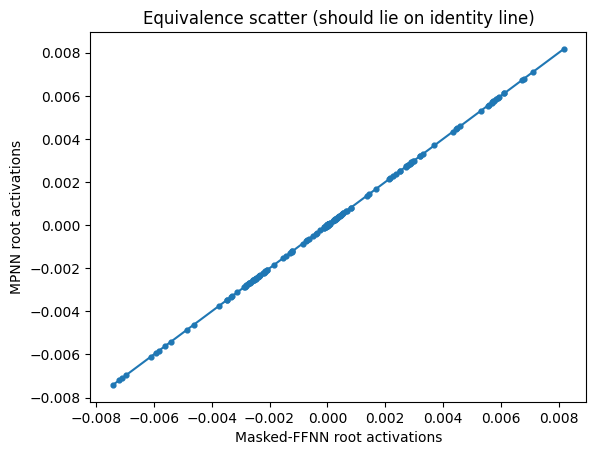

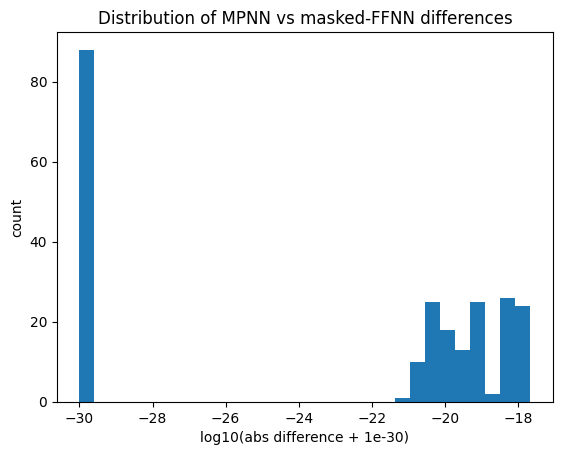

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Preconditions / fallbacks ---
# We expect Phase 5 + Phase 6 to have run. If not, we rebuild minimal pieces.

# Ensure we have a float64 model for clean equivalence plots
if "model_eq" not in globals():
    model_eq = BINNExactLayered(
        N=N_layered,
        E=E_layered,
        L=L,
        root_ids=root_layered_ids,
        is_padding_edge=is_padding_edge,
        learn_padding=False,
    )
    model_eq.load_state_dict(model.state_dict())
    model_eq = model_eq.double()
    model_eq.eval()

# Ensure per-layer lists are in memory
if "edge_index_by_layer" not in globals():
    edge_index_by_layer = torch.load(LAYERED_GRAPH_DIR / "edge_index_by_layer.pt")
if "edge_id_by_layer" not in globals():
    edge_id_by_layer = torch.load(LAYERED_GRAPH_DIR / "edge_id_by_layer.pt")
if "dst_nodes_by_layer" not in globals():
    dst_nodes_by_layer = torch.load(LAYERED_GRAPH_DIR / "dst_nodes_by_layer.pt")

# Gene indices mapping (expr row order -> layered gene ids)
if "gene_layered_ids_in_expr_order" not in globals():
    gene_layered_ids_in_expr_order = torch.load(MAP_PATH)

# Root names for display
if "orig_name" in node_table_layered.columns:
    _root_name_col = "orig_name"
elif "node_name" in node_table_layered.columns:
    _root_name_col = "node_name"
else:
    _root_name_col = None

if _root_name_col is not None:
    root_names = (
        node_table_layered.set_index("layered_id")
        .loc[root_layered_ids.cpu().numpy(), _root_name_col]
        .astype(str)
        .tolist()
    )
else:
    root_names = [str(i) for i in root_layered_ids.cpu().numpy().tolist()]

# Choose which samples to visualize:
# - Prefer the Phase 5 batch if available (shows logits+loss on a batch).
# - Otherwise fall back to the single real sample used in Phase 6.
use_batch = ("batch_samples" in globals()) and ("expr_batch" in globals())
if use_batch:
    samples_vis = list(batch_samples)
    expr_vis = expr_batch
    # Labels tensor
    if "y_t" in globals():
        y_vis = y_t.detach().cpu().numpy().astype(int)
    else:
        y_vis = np.array([int(y.loc[s]) for s in samples_vis], dtype=int)
else:
    # Fall back to the Phase 4 tumor sample
    samples_vis = [sample_tumor]
    expr_vis = expr_small[[sample_tumor]]
    y_vis = np.array([int(y.loc[sample_tumor])], dtype=int)

# --- Compute root activations using BOTH implementations ---
def roots_mpn_from_expr(expr_df: pd.DataFrame, sample_id: str) -> torch.Tensor:
    h0 = torch.zeros((N_layered,), dtype=torch.float64)
    vals = expr_df[sample_id].to_numpy(dtype=np.float64)
    h0[gene_layered_ids_in_expr_order] = torch.from_numpy(vals)
    with torch.no_grad():
        return model_eq(h0, edge_index_by_layer, edge_id_by_layer, dst_nodes_by_layer)

def roots_ffn_from_expr(expr_df: pd.DataFrame, sample_id: str) -> torch.Tensor:
    h0 = torch.zeros((N_layered,), dtype=torch.float64)
    vals = expr_df[sample_id].to_numpy(dtype=np.float64)
    h0[gene_layered_ids_in_expr_order] = torch.from_numpy(vals)
    with torch.no_grad():
        return masked_ffnn_forward_sparsemm(
            h0,
            edge_index_by_layer,
            edge_id_by_layer,
            dst_nodes_by_layer,
            edge_weight=model_eq.edge_weight,
            node_bias=model_eq.node_bias,
            is_padding_edge=is_padding_edge,
            learn_padding=False,
            root_ids=root_layered_ids,
        )

X_mpn = torch.stack([roots_mpn_from_expr(expr_vis, s) for s in samples_vis], dim=0)  # [B, 29]
X_ffn = torch.stack([roots_ffn_from_expr(expr_vis, s) for s in samples_vis], dim=0)  # [B, 29]

assert X_mpn.shape == X_ffn.shape, (X_mpn.shape, X_ffn.shape)
B = X_mpn.shape[0]

# Numeric summary
abs_diff = (X_mpn - X_ffn).abs()
max_abs_diff_all = float(abs_diff.max().item())
max_abs_diff_per_sample = abs_diff.max(dim=1).values.detach().cpu().numpy()

print("Visual equivalence summary:")
print(" - samples:", B)
print(" - root features shape:", tuple(X_mpn.shape))
print(" - max_abs_diff (all entries):", max_abs_diff_all)
print(" - max_abs_diff per sample (first 10):", max_abs_diff_per_sample[:10])

# --- Logits / loss comparison (same head weights for both feature matrices) ---
# Use head from Phase 5 if available; otherwise create a deterministic one.
if "head" in globals():
    head_eq = nn.Linear(X_mpn.shape[1], 2)
    head_eq.load_state_dict(head.state_dict())
    head_eq = head_eq.double()
    head_eq.eval()
else:
    torch.manual_seed(0)
    head_eq = nn.Linear(X_mpn.shape[1], 2).double().eval()

y_vis_t = torch.tensor(y_vis, dtype=torch.long)

with torch.no_grad():
    logits_mpn = head_eq(X_mpn)
    logits_ffn = head_eq(X_ffn)
    loss_mpn = F.cross_entropy(logits_mpn, y_vis_t)
    loss_ffn = F.cross_entropy(logits_ffn, y_vis_t)

max_abs_logit_diff = float((logits_mpn - logits_ffn).abs().max().item())
abs_loss_diff = float((loss_mpn - loss_ffn).abs().item())

print("\nLogits / loss equivalence (using the SAME head weights):")
print(" - logits shape:", tuple(logits_mpn.shape))
print(" - max_abs_logit_diff:", max_abs_logit_diff)
print(" - loss_mpn:", float(loss_mpn.item()))
print(" - loss_ffn:", float(loss_ffn.item()))
print(" - abs(loss_mpn - loss_ffn):", abs_loss_diff)

# --- Make a small table for ONE sample (top roots by abs diff) ---
sample_show = samples_vis[0]
df_show = pd.DataFrame({
    "root_pathway": root_names,
    "mpn": X_mpn[0].detach().cpu().numpy(),
    "ffnn": X_ffn[0].detach().cpu().numpy(),
})
df_show["abs_diff"] = np.abs(df_show["mpn"] - df_show["ffnn"])
df_show = df_show.sort_values("abs_diff", ascending=False)

print("\nTop 10 roots by absolute difference (should all be ~0):")
display(df_show.head(10))

# --- Plot 1: scatter (all samples, all roots) ---
x = X_ffn.detach().cpu().numpy().ravel()
y_sc = X_mpn.detach().cpu().numpy().ravel()

mn = float(min(x.min(), y_sc.min()))
mx = float(max(x.max(), y_sc.max()))

plt.figure()
plt.scatter(x, y_sc, s=12)
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Masked-FFNN root activations")
plt.ylabel("MPNN root activations")
plt.title("Equivalence scatter (should lie on identity line)")
plt.show()

# --- Plot 2: histogram of log10(abs diff) ---
d = abs_diff.detach().cpu().numpy().ravel()
plt.figure()
plt.hist(np.log10(d + 1e-30), bins=30)
plt.xlabel("log10(abs difference + 1e-30)")
plt.ylabel("count")
plt.title("Distribution of MPNN vs masked-FFNN differences")
plt.show()


## 13. What is next

At this point:

- The **layered BINN schedule** is built and cached (Phase 3 artifacts).
- The **BINN-exact forward pass** runs end-to-end on real TCGA gene expression (Phase 4).
- You have verified **batch-style root features** and **logits/loss shapes** (Phase 5), and optionally that gradients flow.
- You now have a **numerical equivalence check** showing the layered MPNN forward matches a masked-FFNN sparse-matrix implementation (Phase 6).

Artifacts now available on disk:

- Phase 1 (data):
  - `expr_reactome_tcga_tumor_normal.parquet`
  - `y_tcga_tumor_normal.csv`

- Phase 2–3 (layered BINN schedule):
  - `graph_layered_binn/edge_index_by_layer.pt`
  - `graph_layered_binn/edge_id_by_layer.pt`
  - `graph_layered_binn/dst_nodes_by_layer.pt`
  - `graph_layered_binn/layer_info.json`

- Phase 4 wiring:
  - `graph_layered_binn/gene_layered_ids_in_expr_order.pt`

Suggested next step (Phase 7):

1. Implement the **actual training loop** for the BINN-exact model (unique edge weights + node biases + classifier head) on the full TCGA dataset.
2. After the BINN-exact replica is trained, add comparison models (GCN, GAT, d>1 embeddings, graph pooling) and evaluate.
3. Optionally, in a separate notebook, run the original `binn` package baseline for comparison.
